# Tarea 3 · Análisis Exploratorio y Métricas del Motor de Validación

**Dataset:** `data/transactions.csv` (10,000 transacciones sintéticas, 2 semanas)
**Resultados del motor:** `data/validation_results.csv` (generado por `batch_processor.py`)

> **Reproducibilidad:** antes de ejecutar este notebook, correr
> `python batch_processor.py --input data/transactions.csv --output data/validation_results.csv`

Secciones: calidad de datos → distribución de montos → análisis temporal → resultados de validación → perfil de cuentas riesgosas → precisión/recall vs `is_flagged` → hallazgos y recomendaciones.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

SEVERITY_COLOR = {"CRITICA": "#c0392b", "ALTA": "#e67e22", "MEDIA": "#f1c40f", "BAJA": "#3498db"}
STATUS_COLOR = {"APPROVED": "#27ae60", "REJECTED": "#c0392b", "REVIEW": "#f39c12", "ERROR": "#7f8c8d"}

tx = pd.read_csv("data/transactions.csv")
vr = pd.read_csv("data/validation_results.csv")
vr["ts"] = pd.to_datetime(vr["timestamp"], utc=True)
print(f"Transacciones: {len(tx):,} | Resultados: {len(vr):,}")
print(f"Rango temporal: {vr.ts.min()} -> {vr.ts.max()}")
print(f"Cuentas únicas: {vr.account_id.nunique()}")

Transacciones: 10,000 | Resultados: 10,000
Rango temporal: 2025-01-01 00:09:14+00:00 -> 2025-01-13 23:56:55+00:00
Cuentas únicas: 500


## 1 · Calidad de datos

Los nulos del dataset se concentran en `country_code` y `merchant_category` (los campos opcionales del esquema) y en `amount` (18 casos, insumo directo de RG-001). Los campos obligatorios llegan completos, por lo que RG-008 actúa como *guardrail* sin disparos en este lote.

In [2]:
quality = pd.DataFrame({
    "dtype": tx.dtypes.astype(str),
    "nulos": tx.isna().sum(),
    "% nulos": (tx.isna().mean() * 100).round(2),
    "únicos": tx.nunique(),
})
quality

,dtype,nulos,% nulos,únicos
transaction_id,str,0,0.00,10000
account_id,str,0,0.00,500
amount,float64,18,0.18,9945
currency,str,0,0.00,9
transaction_type,str,0,0.00,4
timestamp,str,0,0.00,9960
country_code,str,198,1.98,15
merchant_category,str,301,3.01,10
account_age_days,int64,0,0.00,1819
daily_tx_count,int64,0,0.00,22


## 2 · Distribución de montos

Percentiles, outliers (criterio IQR) y forma de la distribución. El dato clave: **la mediana de un solo monto es prácticamente igual al límite diario de RG-002 ($50,000)**, lo que anticipa la altísima tasa de violación de esa regla.

media  = $ 50,026.37
p50    = $ 49,082.86
p90    = $ 90,497.40
p99    = $ 99,737.55
máximo = $202,166.88
outliers IQR = 47 (0.47% de los montos)


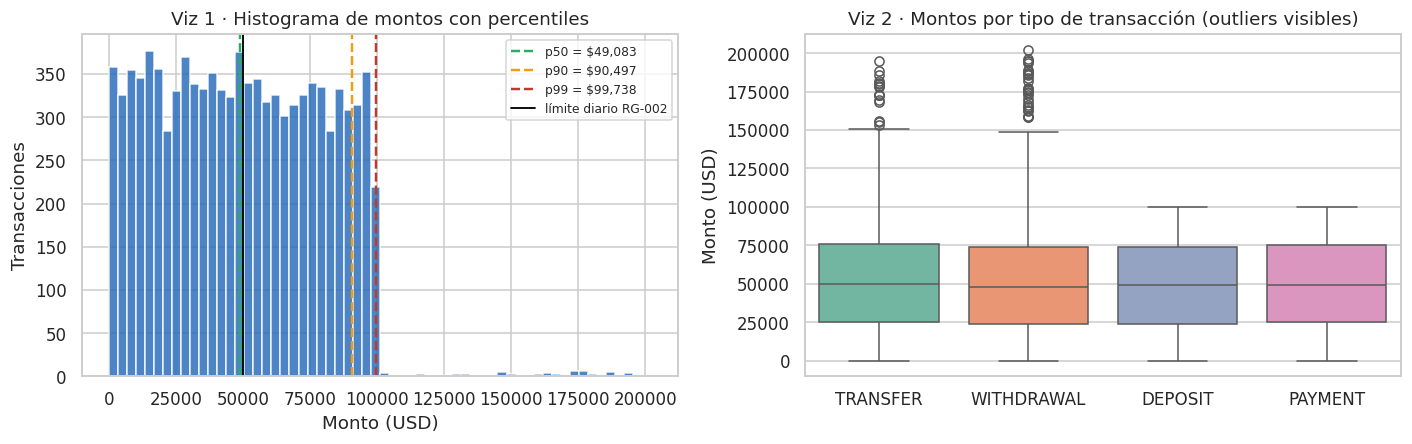

In [3]:
amounts = vr["amount"].dropna()
p50, p90, p99 = amounts.quantile([0.50, 0.90, 0.99])
q1, q3 = amounts.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (amounts < q1 - 1.5 * iqr) | (amounts > q3 + 1.5 * iqr)

print(f"media  = ${amounts.mean():>10,.2f}")
print(f"p50    = ${p50:>10,.2f}")
print(f"p90    = ${p90:>10,.2f}")
print(f"p99    = ${p99:>10,.2f}")
print(f"máximo = ${amounts.max():>10,.2f}")
print(f"outliers IQR = {outlier_mask.sum()} ({outlier_mask.mean()*100:.2f}% de los montos)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(amounts, bins=60, color="#2c6fbb", alpha=0.85, edgecolor="white")
for value, label, color in [(p50, "p50", "#27ae60"), (p90, "p90", "#f39c12"), (p99, "p99", "#c0392b")]:
    axes[0].axvline(value, color=color, linestyle="--", linewidth=1.6, label=f"{label} = ${value:,.0f}")
axes[0].axvline(50_000, color="black", linewidth=1.2, label="límite diario RG-002")
axes[0].set_title("Viz 1 · Histograma de montos con percentiles")
axes[0].set_xlabel("Monto (USD)")
axes[0].set_ylabel("Transacciones")
axes[0].legend(fontsize=8)

sns.boxplot(data=vr, x="transaction_type", y="amount", hue="transaction_type",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Viz 2 · Montos por tipo de transacción (outliers visibles)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Monto (USD)")
plt.tight_layout()
plt.show()

## 3 · Análisis temporal

Volumen por hora del día y por día de la semana. **Nota metodológica:** la ventana de 13 días (2025-01-01 → 2025-01-13) contiene **una sola ocurrencia de martes** y dos de cada otro día; comparar totales crudos haría parecer que "los martes cae el volumen". Por eso el gráfico de días muestra el **promedio por ocurrencia** del día.

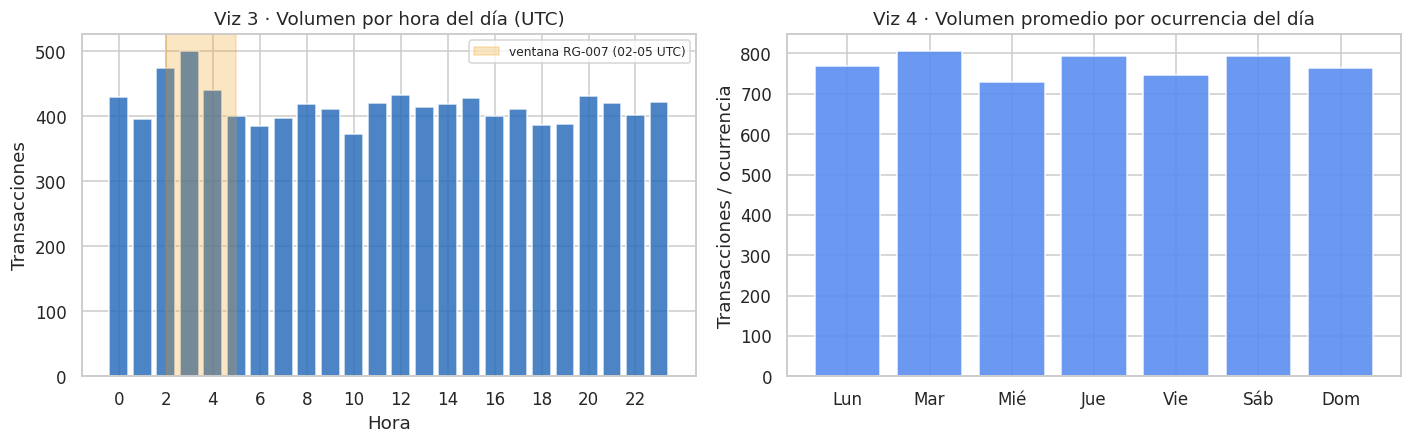

Ocurrencias de cada día en la ventana: {'Monday': 2, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 2, 'Friday': 2, 'Saturday': 2, 'Sunday': 2}


In [4]:
hourly = vr.ts.dt.hour.value_counts().sort_index()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_labels = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
occurrences = pd.Series(pd.to_datetime(vr.ts.dt.date.unique()).day_name()).value_counts()
per_day_total = vr.ts.dt.day_name().value_counts()
per_day_avg = (per_day_total / occurrences).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].bar(hourly.index, hourly.values, color="#2c6fbb", alpha=0.85)
axes[0].axvspan(2, 5, color="#f39c12", alpha=0.25, label="ventana RG-007 (02-05 UTC)")
axes[0].set_title("Viz 3 · Volumen por hora del día (UTC)")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Transacciones")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8)

axes[1].bar(day_labels, per_day_avg.values, color="#5b8def", alpha=0.9)
axes[1].set_title("Viz 4 · Volumen promedio por ocurrencia del día")
axes[1].set_ylabel("Transacciones / ocurrencia")
plt.tight_layout()
plt.show()

print("Ocurrencias de cada día en la ventana:", occurrences.reindex(day_order).astype(int).to_dict())

## 4 · Resultados de validación

Distribución del estado final, frecuencia de violación por regla y correlación entre reglas.

> **Sesgo de cortocircuito:** por diseño, una violación CRÍTICA detiene la cadena, así que las reglas posteriores al corte no llegan a evaluarse. La co-ocurrencia observada es, por tanto, un **piso** de la co-ocurrencia real.

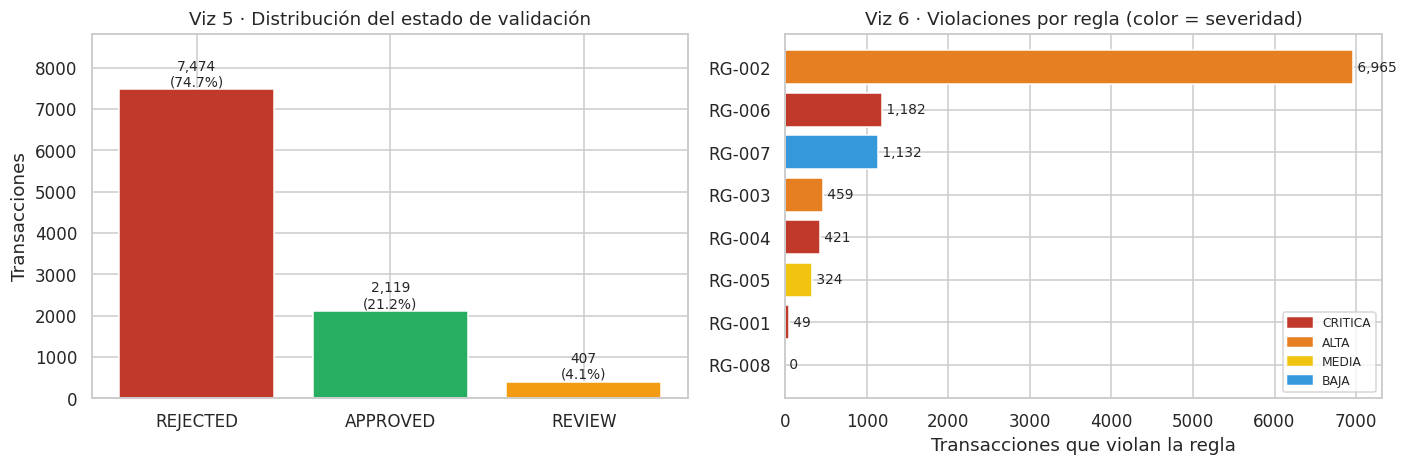

In [5]:
status_counts = vr["validation_status"].value_counts()

RULES = ["RG-001", "RG-002", "RG-003", "RG-004", "RG-005", "RG-006", "RG-007", "RG-008"]
SEVERITY = {"RG-001": "CRITICA", "RG-002": "ALTA", "RG-003": "ALTA", "RG-004": "CRITICA",
            "RG-005": "MEDIA", "RG-006": "CRITICA", "RG-007": "BAJA", "RG-008": "CRITICA"}
flags = pd.DataFrame({r: vr["violated_rules"].fillna("").str.contains(r) for r in RULES})
rule_counts = flags.sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].bar(status_counts.index, status_counts.values,
            color=[STATUS_COLOR[s] for s in status_counts.index])
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/len(vr)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, status_counts.max() * 1.18)
axes[0].set_title("Viz 5 · Distribución del estado de validación")
axes[0].set_ylabel("Transacciones")

axes[1].barh(rule_counts.index, rule_counts.values,
             color=[SEVERITY_COLOR[SEVERITY[r]] for r in rule_counts.index])
for i, (r, v) in enumerate(rule_counts.items()):
    axes[1].text(v, i, f" {v:,}", va="center", fontsize=9)
axes[1].set_title("Viz 6 · Violaciones por regla (color = severidad)")
axes[1].set_xlabel("Transacciones que violan la regla")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SEVERITY_COLOR.values()]
axes[1].legend(handles, SEVERITY_COLOR.keys(), fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

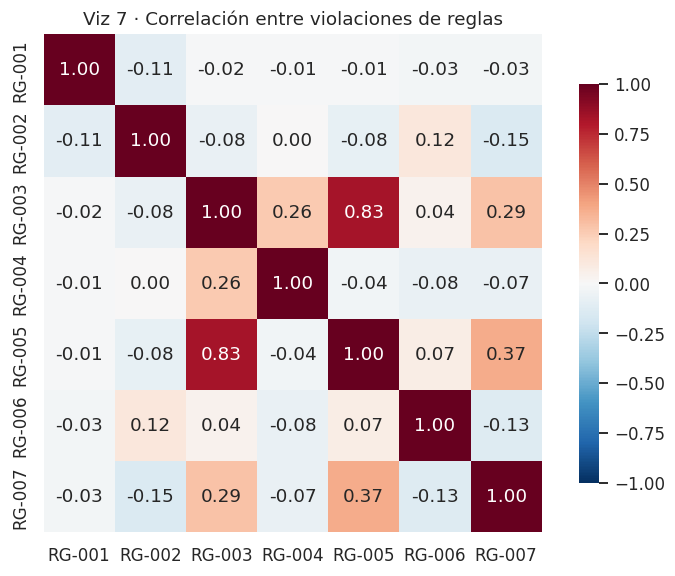

RG-005 ∩ RG-003 = 324 de 324 marcas RG-005 (100%): el país de riesgo llega siempre desde cuentas nuevas con alta frecuencia.
RG-008 no disparó en el lote (campos obligatorios completos); su comportamiento queda cubierto por tests unitarios.


In [6]:
# Correlación (phi) entre reglas; se excluyen reglas sin disparos (varianza cero)
active = flags.loc[:, flags.sum() > 0].astype(int)
corr = active.corr()

plt.figure(figsize=(7.2, 5.4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8})
plt.title("Viz 7 · Correlación entre violaciones de reglas")
plt.tight_layout()
plt.show()

co_0503 = int((flags["RG-005"] & flags["RG-003"]).sum())
print(f"RG-005 ∩ RG-003 = {co_0503} de {int(flags['RG-005'].sum())} marcas RG-005 "
      f"({co_0503/flags['RG-005'].sum()*100:.0f}%): el país de riesgo llega siempre "
      "desde cuentas nuevas con alta frecuencia.")
print("RG-008 no disparó en el lote (campos obligatorios completos); su comportamiento "
      "queda cubierto por tests unitarios.")

## 5 · Perfil de cuentas riesgosas

Métricas agregadas por `account_id`: volumen, monto, tasa de rechazo y fraude marcado.

,n_tx,monto_total,monto_promedio,rechazadas,en_revision,fraudes_marcados,edad_cuenta,tasa_rechazo
account_id,,,,,,,,
a6591376-83d5-4cc2-b4d6-e2e2202697ad,17,"906,257.22","53,309.25",17,0,2,1664,1.00
194e5fc7-79fe-4225-9f00-46c050577581,30,"1,675,531.01","55,851.03",29,0,3,1630,0.97
b983de7f-6242-4a76-bc72-6ad271aa7c31,29,"1,504,626.57","51,883.67",28,0,3,1751,0.97
1c84547c-9805-436d-8f0f-1355ed797ded,23,"1,442,463.91","62,715.82",22,0,4,1695,0.96
f1dd08d7-1a80-4ec1-875b-335b5ebb412a,21,"1,231,803.86","58,657.33",20,1,1,1818,0.95
51eaa112-6186-4347-ac8b-797710a37696,18,"1,135,582.93","63,087.94",17,0,0,1759,0.94
e628a974-0960-406f-a339-04c2b2a41df0,17,"936,147.12","55,067.48",16,0,0,1819,0.94
4821c93f-2d7b-4244-93ee-78818a38bd56,26,"1,448,504.30","55,711.70",24,1,3,1704,0.92
a6d713f1-9f1c-4ef5-b238-aae016a33836,26,"1,259,718.18","48,450.70",24,1,2,1790,0.92


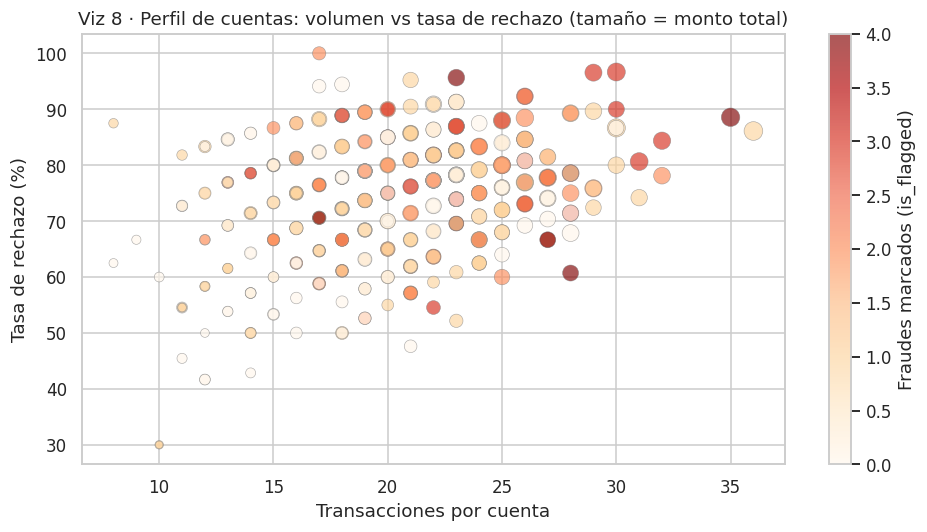

In [7]:
accounts = (
    vr.groupby("account_id")
      .agg(
          n_tx=("transaction_id", "count"),
          monto_total=("amount", "sum"),
          monto_promedio=("amount", "mean"),
          rechazadas=("validation_status", lambda s: (s == "REJECTED").sum()),
          en_revision=("validation_status", lambda s: (s == "REVIEW").sum()),
          fraudes_marcados=("is_flagged", "sum"),
          edad_cuenta=("account_age_days", "max"),
      )
)
accounts["tasa_rechazo"] = accounts["rechazadas"] / accounts["n_tx"]

top = accounts.sort_values(["tasa_rechazo", "monto_total"], ascending=False).head(10)
display(top)

plt.figure(figsize=(9, 5))
scatter = plt.scatter(accounts["n_tx"], accounts["tasa_rechazo"] * 100,
                      s=accounts["monto_total"] / 12_000,
                      c=accounts["fraudes_marcados"], cmap="OrRd", alpha=0.65,
                      edgecolors="grey", linewidths=0.4)
plt.colorbar(scatter, label="Fraudes marcados (is_flagged)")
plt.xlabel("Transacciones por cuenta")
plt.ylabel("Tasa de rechazo (%)")
plt.title("Viz 8 · Perfil de cuentas: volumen vs tasa de rechazo (tamaño = monto total)")
plt.tight_layout()
plt.show()

## 6 · Recall vs `is_flagged`: ¿el motor detecta el fraude marcado?

Se comparan dos definiciones de "positivo" del motor contra la verdad de campo `is_flagged`:

* **Estricta:** positivo = `REJECTED`
* **Laxa:** positivo = `REJECTED` ∪ `REVIEW`

,TP,FP,FN,TN,precision,recall,f1
estricta (REJECTED),365,7109,117,2409,0.049,0.757,0.092
laxa (REJ+REV),379,7502,103,2016,0.048,0.786,0.091


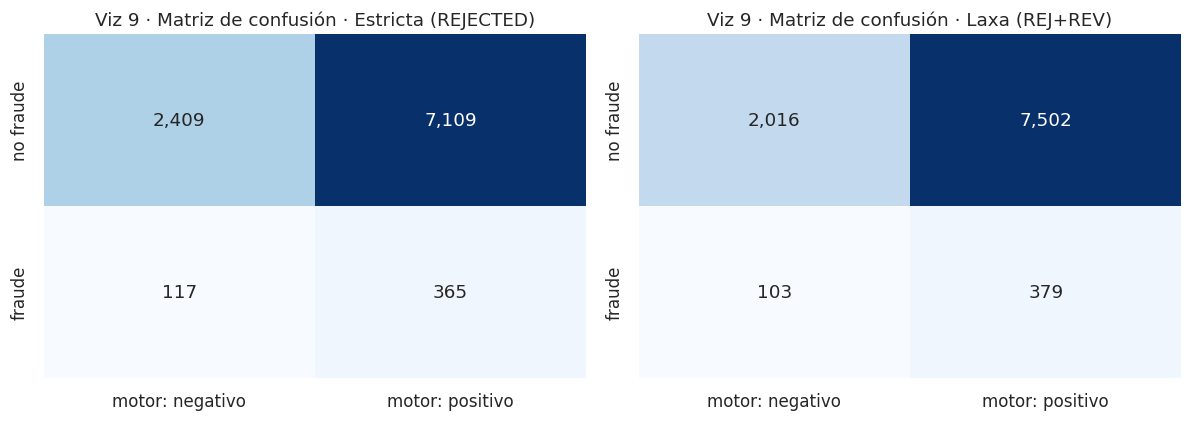

Tasa de fraude por estado del motor:
validation_status
APPROVED    4.86 %
REJECTED    4.88 %
REVIEW      3.44 %
Name: is_flagged, dtype: str
Tasa base de fraude del dataset: 4.82 %


In [8]:
def engine_metrics(pred: pd.Series, truth: pd.Series) -> dict:
    tp = int((pred & truth).sum())
    fp = int((pred & ~truth).sum())
    fn = int((~pred & truth).sum())
    tn = int((~pred & ~truth).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": precision, "recall": recall, "f1": f1}

truth = vr["is_flagged"].astype(bool)
strict = engine_metrics(vr["validation_status"].eq("REJECTED"), truth)
loose = engine_metrics(vr["validation_status"].isin(["REJECTED", "REVIEW"]), truth)

metrics = pd.DataFrame([strict, loose], index=["estricta (REJECTED)", "laxa (REJ+REV)"])
display(metrics.style.format({"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, m) in zip(axes, [("Estricta (REJECTED)", strict), ("Laxa (REJ+REV)", loose)]):
    cm = np.array([[m["TN"], m["FP"]], [m["FN"], m["TP"]]])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["motor: negativo", "motor: positivo"],
                yticklabels=["no fraude", "fraude"])
    ax.set_title(f"Viz 9 · Matriz de confusión · {name}")
plt.tight_layout()
plt.show()

print("Tasa de fraude por estado del motor:")
print((vr.groupby("validation_status")["is_flagged"].mean() * 100).round(2).astype(str) + " %")
print(f"Tasa base de fraude del dataset: {truth.mean()*100:.2f} %")

In [9]:
# Lift de fraude por regla: ¿alguna regla concentra fraude por encima de la base?
base_rate = truth.mean()
lift_rows = []
for rule in RULES:
    hits = flags[rule]
    if hits.sum() == 0:
        continue
    fraud_rate = truth[hits].mean()
    lift_rows.append({"regla": rule, "transacciones": int(hits.sum()),
                      "tasa_fraude": fraud_rate, "lift_vs_base": fraud_rate / base_rate})
lift = pd.DataFrame(lift_rows).set_index("regla").sort_values("lift_vs_base", ascending=False)
lift.style.format({"tasa_fraude": "{:.3f}", "lift_vs_base": "{:.2f}x"})

,transacciones,tasa_fraude,lift_vs_base
regla,,,
RG-005,324,0.071,1.47x
RG-003,459,0.068,1.40x
RG-001,49,0.061,1.27x
RG-002,6965,0.049,1.01x
RG-007,1132,0.042,0.86x
RG-004,421,0.040,0.84x
RG-006,1182,0.039,0.81x


## 7 · Hallazgos y recomendaciones

### Hallazgos

1. **RG-002 está descalibrada frente a este portafolio y domina el motor.** El 69.7% de las transacciones viola el límite diario de $50,000 porque la mediana de *un solo* monto ($49,083) ya es prácticamente el límite; con la acumulación diaria por cuenta, el rechazo es casi inevitable. El resultado global — 74.7% `REJECTED`, 21.2% `APPROVED`, 4.1% `REVIEW`, 0 errores — está determinado por esta sola regla.

2. **Las reglas de cumplimiento no discriminan el fraude marcado.** La precisión del motor (4.9% estricta, 4.8% laxa) coincide con la tasa base de fraude (4.82%), y la tasa de fraude es casi idéntica entre transacciones aprobadas (4.86%) y rechazadas (4.88%). El recall de 75.7% es un artefacto de rechazar el 74.7% de todo, no de capacidad de detección. El F1 de 0.09 confirma que **este motor es un control de cumplimiento, no un modelo antifraude** — y ambos objetivos no deben confundirse.

3. **Existe una "persona de riesgo" consistente en el dataset.** Las 382 transacciones de países de alto riesgo (IR, KP, SY, CU, VE) fueron rechazadas en su totalidad, y el 100% de las marcas RG-005 co-ocurre con RG-003: provienen de cuentas con menos de 30 días y más de 20 transacciones diarias. En esos países la regla más frecuente deja de ser RG-002 y pasa a ser RG-003 (ver Q3 de `queries.sql`). Las monedas no aprobadas (IRR, KPW, MMK, VES; 421 casos de RG-004) pertenecen al mismo cohorte.

4. **La cola de revisión manual es manejable y monotemática.** Los 407 `REVIEW` provienen exclusivamente de RG-007 (monto > $5,000 entre 02:00–05:00 UTC), ~31 casos/día. RG-005 nunca produce un `REVIEW` final porque sus transacciones siempre caen también en reglas de rechazo.

5. **El "bajón de los martes" es un artefacto de calendario.** La ventana de 13 días contiene una sola ocurrencia de martes; normalizado por ocurrencia, el volumen diario es estable (~730–795 tx/día).

6. **RG-008 no disparó en el lote** porque los campos obligatorios llegan completos (los nulos intencionales están en los opcionales `country_code` y `merchant_category`); su comportamiento queda garantizado por tests unitarios. RG-001 capturó exactamente los 49 montos inválidos del dataset (18 nulos + 31 ≤ 0).

### Recomendaciones

* **Recalibrar RG-002 con Cumplimiento:** validar la escala de montos del dataset y/o segmentar el límite diario por perfil de cuenta (antigüedad, historial). Un límite uniforme de $50k con esta distribución convierte la regla en ruido operativo.
* **Separar cumplimiento de detección de fraude:** mantener el motor de reglas como control determinístico y auditable, y complementarlo con un score supervisado entrenado con `is_flagged` (features candidatas: edad de cuenta × frecuencia, hora, cohorte país/moneda). El lift de RG-005 (1.47x) y RG-003 (1.41x) sugiere que esas señales aportan, pero solas son insuficientes.
* **Priorizar KYC reforzado para cuentas nuevas de alta frecuencia,** que concentran toda la cohorte de países de riesgo.
* **Operacionalizar la cola REVIEW:** definir SLA de revisión para los ~31 casos/día de RG-007 y activar la alerta de Q4 (más de 3 REVIEW por cuenta en 24 h) en streaming, aunque hoy no dispare.
* **Monitorear la tasa de rechazo como métrica de salud del motor:** un 74.7% sostenido en producción indicaría reglas descalibradas mucho antes que cualquier queja de cliente.